# Utilities testing notebook

The notebook is intended to test the utilities in the `utils` directory, such as dataset loading, preprocessing, and augmentation functions. It will also include examples of how to use these utilities in a typical machine learning workflow.

---
## Setting up paths

In [2]:
import os
import sys
from pathlib import Path

pd = os.getcwd()
project_root = os.path.abspath(os.path.join(pd, ".."))
utils_path = os.path.join(project_root, "utils")

print(f"Current working directory: {pd}")
print(f"Project root: {project_root}")
print(f"Utils path: {utils_path}")

for p in [project_root, utils_path]:
    if p not in sys.path:
        sys.path.insert(0, p)

Current working directory: /home/hai/git/WGAN-SOC/notebooks
Project root: /home/hai/git/WGAN-SOC
Utils path: /home/hai/git/WGAN-SOC/utils


## Dataset downloading

- SOFC Microstructures (PFIB-SEM and synthetic) from JPS 2018
- doi: 10.18141/1425617

The dataset is pulled from edx. This is data from the publication "Mesoscale charaterization of local property distribution in hetergeneous electrodes" by Tim Hsu. 

In [3]:
DOWNLOAD_URL = "https://edx.netl.doe.gov/resource/20435741-a7e7-45f7-91a3-e125f8b05b11/download"
OUTPUT_DIR = "data"
FILE_NAME = "edx_doe_data.zip"

In [4]:
from datasets import download_file

final_path = download_file(DOWNLOAD_URL, OUTPUT_DIR, FILE_NAME, extract=True)

File already exists: data/edx_doe_data.zip


Extracting edx_doe_data.zip: 100%|██████████| 127/127 [00:00<00:00, 130.79file/s]

Extracted data/edx_doe_data.zip to data/edx_doe_data


In [5]:
data_path = Path(final_path) / Path(os.listdir(final_path)[0])
os.listdir(data_path)[:5]

['anode_segmented_tiff_z049.tif',
 'anode_segmented_tiff_z080.tif',
 'anode_segmented_tiff_z008.tif',
 'anode_segmented_tiff_z050.tif',
 'anode_segmented_tiff_z062.tif']

## Data Loading

In [6]:
uom_file_path = Path("data/uom/Cell_0A.mat")

In [7]:
from scipy.io import loadmat
uom_data = loadmat(uom_file_path)
uom_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'vol_seg'])

In [8]:
print(f"Data shape: {uom_data['vol_seg'].shape}")
print(f"Data samples: {uom_data['vol_seg'][:2]}")

Data shape: (400, 1050, 301)
Data samples: [[[2 2 2 ... 1 2 2]
  [2 2 2 ... 1 2 2]
  [2 2 2 ... 1 2 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]

 [[2 2 2 ... 1 1 2]
  [2 2 2 ... 1 1 2]
  [2 2 2 ... 1 1 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]]


In [9]:
uom_data['vol_seg'].min(), uom_data['vol_seg'].max()

(np.uint8(1), np.uint8(3))

In [10]:
# The mat file is a 3D volume of shape (400, 1050, 301). Each voxel is labeled as either 0 (pores), 1 (Ni), or 2 (YSZ).
# Visualize the data using k3d
import numpy as np
import k3d

# Use uint8 as strictly required by k3d.voxels, avoiding forced memory copies.
# Values 0, 1, and 2 easily fit in uint8 without overflow.
vol_seg = np.asarray(uom_data["vol_seg"], dtype=np.uint8)[...,:5]

# Keep labels in the expected range [0, 2], right now the range is 1 to 3, so we need to shift it down by 1.
vol_seg -= 1

plot = k3d.plot()
plot += k3d.voxels(
    vol_seg,
    color_range=[0, 2],
    opacity=0.5,
)
plot.display()

Output()

---

# Conditional SliceGAN — Data Pipeline

| Problem | Solution |
|---|---|
| Data lives in MATLAB `.mat` files with non-zero phase labels (`1, 2, 3`) | `load_mat_volume` — loads and validates the file, prints shape and unique labels |
| Raw volumes are too large and irregular (e.g. `400×1050×301`) to train on directly | `extract_subvolumes` — grids the volume into cubic patches, rejects near-homogeneous ones |
| Limited data → need augmentation | `augment_volume` — random 90° rotations + mirror flips that preserve phase statistics |
| Model needs a conditioning signal | `compute_conditioning_vector` — computes `[vf₀…vfₙ, ps₀…psₙ]` per patch |
| SliceGAN's `batch()` expects `TensorDataset` lists | Extended `preprocessing.batch` supports `type='mat3D'` end-to-end |

The pipeline flows as:

```
.mat file  →  load_mat_volume
           →  extract_subvolumes   (grid + coverage filter)
           →  augment_volume       (rot90 + flip)
           →  one-hot encode       (labels 1,2,3 → channels 0,1,2)
           →  random 2D slice      (per axis: x, y, z)
           →  TensorDataset × 3   (ready for SliceGAN DataLoader)
```

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from slicegan import (
    load_mat_volume,
    extract_subvolumes,
    augment_volume,
    compute_volume_fraction,
    compute_average_pore_size,
    compute_conditioning_vector,
    compute_dataset_conditioning_stats,
    # batch, --- IGNORE ---
)

# Consistent colour map across all plots: phase 1=blue, phase 2=orange, phase 3=green
PHASE_CMAP = ListedColormap(["#4C72B0", "#DD8452", "#55A868"])
PHASE_LABELS = ["Phase 1 (Pores)", "Phase 2 (Ni)", "Phase 3 (YSZ)"]

MAT_PATH = "data/uom/Cell_0A.mat"
print("All imports OK.")

All imports OK.


## 1. `load_mat_volume` — Loading the raw .mat file

MATLAB `.mat` files are the primary data format for this project. The raw volume from the University of Manchester dataset (`Cell_0A.mat`) has shape `(400, 1050, 301)` with integer phase labels `1`, `2`, `3`.

`load_mat_volume` wraps `scipy.io.loadmat`, extracts the `vol_seg` key, and prints a summary so we can immediately sanity-check the data before any processing begins. It raises a descriptive `KeyError` if the expected key is missing — a common source of silent failures with `.mat` files.

In [21]:
vol = load_mat_volume(MAT_PATH)

print(f"\nVolume shape : {vol.shape}")
print(f"dtype        : {vol.dtype}")
print(f"Phase labels : {np.unique(vol).tolist()}")
print(f"Total voxels : {vol.size:,}")

[load_mat_volume] shape=(400, 1050, 301), unique labels=[1, 2, 3]

Volume shape : (400, 1050, 301)
dtype        : int32
Phase labels : [1, 2, 3]
Total voxels : 126,420,000


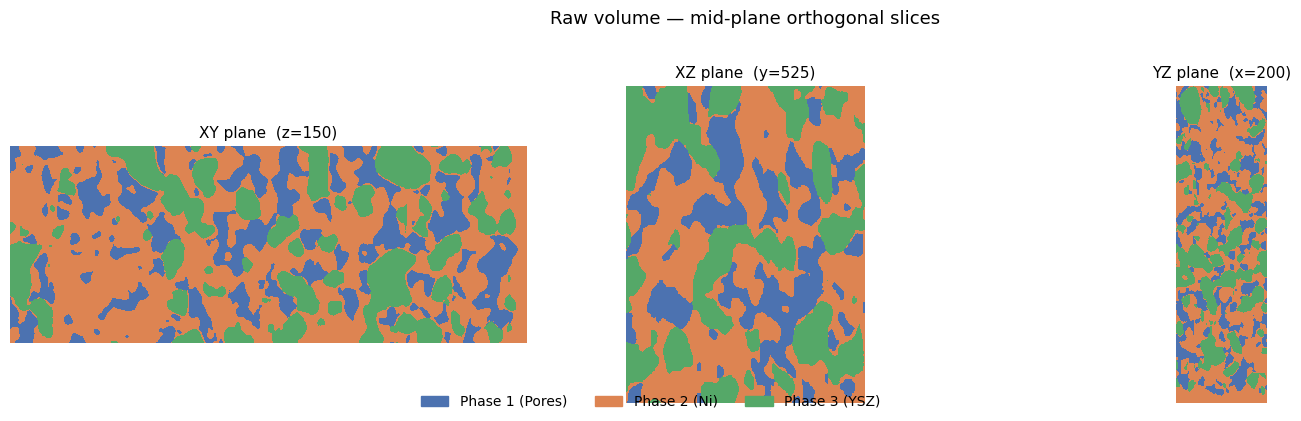

In [22]:
# Visualise orthogonal mid-plane slices of the raw volume
mid = [s // 2 for s in vol.shape]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = [f"XY plane  (z={mid[2]})", f"XZ plane  (y={mid[1]})", f"YZ plane  (x={mid[0]})"]
slices = [vol[:, :, mid[2]], vol[:, mid[1], :], vol[mid[0], :, :]]

for ax, sl, title in zip(axes, slices, titles):
    im = ax.imshow(sl, cmap=PHASE_CMAP, vmin=1, vmax=3, interpolation="nearest")
    ax.set_title(title, fontsize=11)
    ax.axis("off")

patches = [mpatches.Patch(color=PHASE_CMAP(i / 2), label=PHASE_LABELS[i]) for i in range(3)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, frameon=False)
fig.suptitle("Raw volume — mid-plane orthogonal slices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. `extract_subvolumes` — Dividing the volume into training patches

The raw volume (`400×1050×301`) is far too large to feed directly into a generator that outputs `64³` cubes. We grid it into overlapping or non-overlapping cubic subvolumes.

The **coverage filter** (`min_phase_coverage`) is critical: a nearly homogeneous patch (e.g. 99% pore, 1% Ni) provides almost no gradient signal for the phases that are under-represented. By rejecting such patches we keep only those with at least `min_phase_coverage` of *every* phase, ensuring the training set reflects the true multi-phase texture.

- **`stride = subvol_size`** → non-overlapping grid (maximum diversity per patch)  
- **`stride < subvol_size`** → overlapping grid (more patches from limited data, at the cost of redundancy)

In [23]:
SUBVOL_SIZE = 64

# Non-overlapping extraction with coverage filter
subvols = extract_subvolumes(vol, subvol_size=SUBVOL_SIZE, stride=SUBVOL_SIZE, min_phase_coverage=0.05)

print(f"\nSubvolume size : {SUBVOL_SIZE}³")
print(f"Accepted       : {len(subvols)}")
print(f"Each shape     : {subvols[0].shape}")

[extract_subvolumes] extracted=336, rejected=48 (min_phase_coverage=0.05)

Subvolume size : 64³
Accepted       : 336
Each shape     : (64, 64, 64)


[extract_subvolumes] extracted=384, rejected=0 (min_phase_coverage=0.0)
[extract_subvolumes] extracted=368, rejected=16 (min_phase_coverage=0.01)
[extract_subvolumes] extracted=336, rejected=48 (min_phase_coverage=0.05)
[extract_subvolumes] extracted=279, rejected=105 (min_phase_coverage=0.1)
[extract_subvolumes] extracted=118, rejected=266 (min_phase_coverage=0.2)


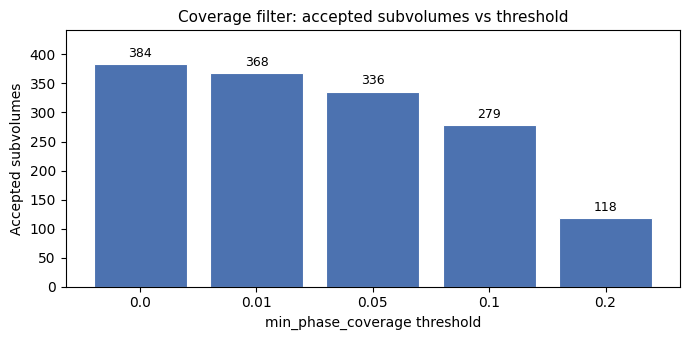

In [24]:
# Compare accepted counts for different coverage thresholds
thresholds = [0.0, 0.01, 0.05, 0.10, 0.20]
counts = []
for t in thresholds:
    sv = extract_subvolumes(vol, subvol_size=SUBVOL_SIZE, stride=SUBVOL_SIZE,
                             min_phase_coverage=t)
    counts.append(len(sv))

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar([str(t) for t in thresholds], counts, color="#4C72B0", edgecolor="white", linewidth=0.8)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("min_phase_coverage threshold", fontsize=10)
ax.set_ylabel("Accepted subvolumes", fontsize=10)
ax.set_title("Coverage filter: accepted subvolumes vs threshold", fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

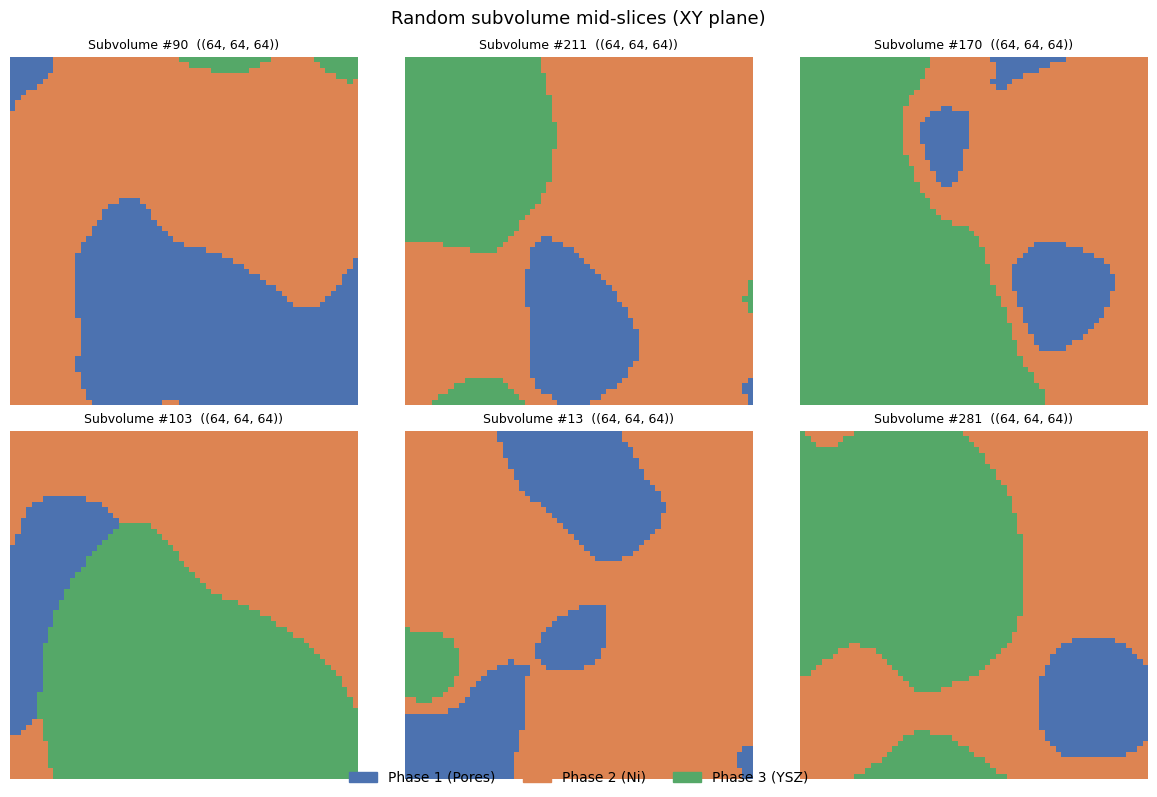

In [25]:
# Show mid-plane XY slices of 6 randomly sampled subvolumes
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(subvols), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    sv = subvols[idx]
    ax.imshow(sv[:, :, sv.shape[2] // 2], cmap=PHASE_CMAP, vmin=1, vmax=3, interpolation="nearest")
    ax.set_title(f"Subvolume #{idx}  ({sv.shape})", fontsize=9)
    ax.axis("off")

patches = [mpatches.Patch(color=PHASE_CMAP(i / 2), label=PHASE_LABELS[i]) for i in range(3)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, frameon=False)
fig.suptitle("Random subvolume mid-slices (XY plane)", fontsize=13)
plt.tight_layout()
plt.show()

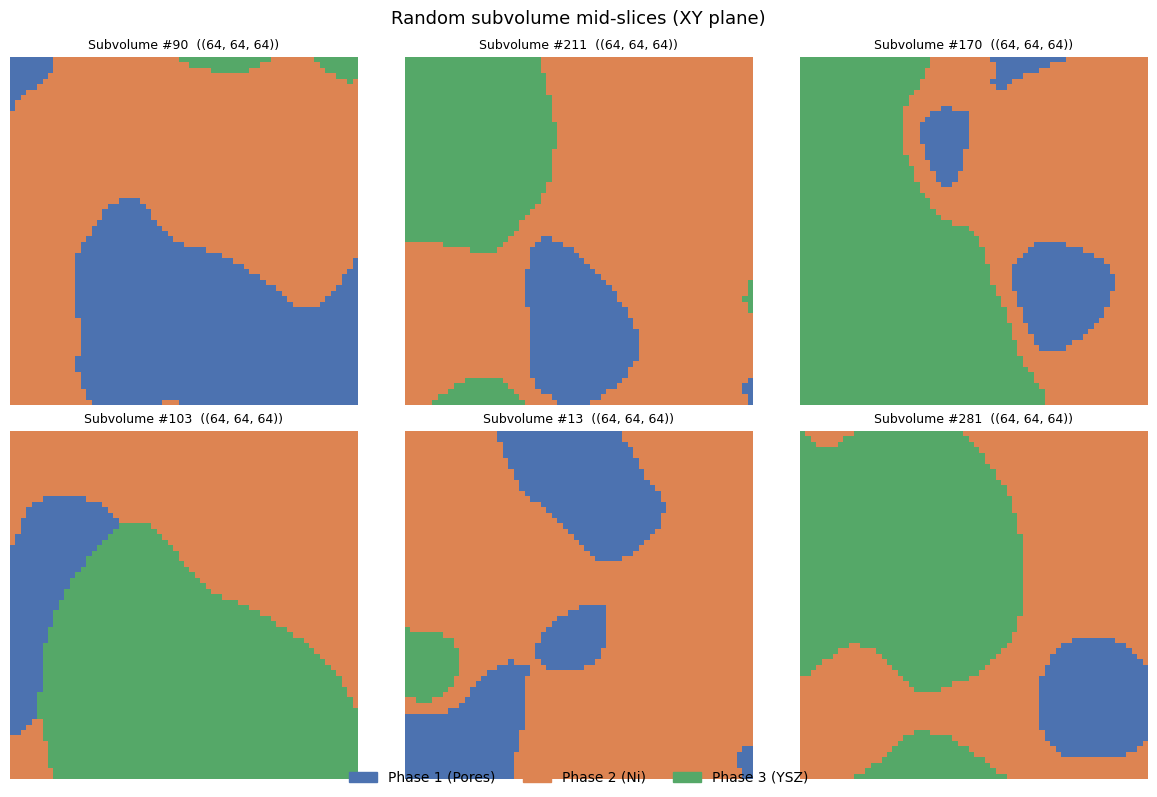

In [26]:
# Show mid-plane XY slices of 6 randomly sampled subvolumes
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(subvols), size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    sv = subvols[idx]
    ax.imshow(sv[:, :, sv.shape[2] // 2], cmap=PHASE_CMAP, vmin=1, vmax=3, interpolation="nearest")
    ax.set_title(f"Subvolume #{idx}  ({sv.shape})", fontsize=9)
    ax.axis("off")

patches = [mpatches.Patch(color=PHASE_CMAP(i / 2), label=PHASE_LABELS[i]) for i in range(3)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, frameon=False)
fig.suptitle("Random subvolume mid-slices (XY plane)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. `augment_volume` — Data augmentation via symmetry

With only ~30–100 accepted subvolumes from a single `.mat` file, the training set is sparse. We exploit the physical isotropy of the SOFC anode microstructure: any rotation by a multiple of 90° about any axis, and any mirror flip, produces a statistically equivalent sample.

`augment_volume` applies:
- Random 90° rotations on each of the three axis-pairs `(0,1)`, `(0,2)`, `(1,2)` → up to `4³ = 64` orientations
- Random mirror flips along each axis → up to `2³ = 8` reflections

Combined: up to **512 distinct orientations** per subvolume, all of which are physically valid training samples. Volume fractions are provably invariant under these operations (just counting voxels), which is verified in the test suite.

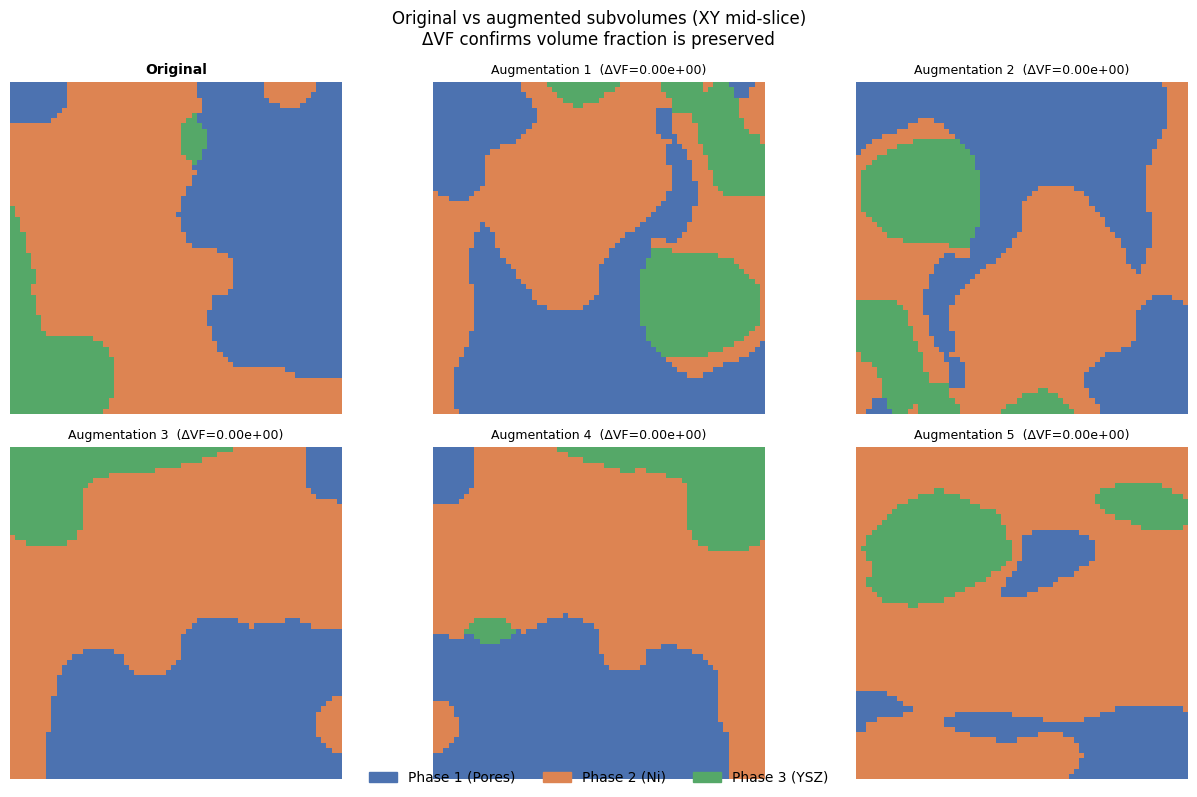

In [27]:
np.random.seed(7)
original = subvols[0].copy()
augmented_versions = [augment_volume(original.copy()) for _ in range(5)]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# Original in top-left
axes[0, 0].imshow(original[:, :, original.shape[2] // 2],
                  cmap=PHASE_CMAP, vmin=1, vmax=3, interpolation="nearest")
axes[0, 0].set_title("Original", fontsize=10, fontweight="bold")
axes[0, 0].axis("off")

for i, aug in enumerate(augmented_versions):
    ax = axes.flat[i + 1]
    ax.imshow(aug[:, :, aug.shape[2] // 2],
              cmap=PHASE_CMAP, vmin=1, vmax=3, interpolation="nearest")

    # Verify VF invariance
    total = aug.size
    vf_diff = max(abs((original == ph).sum() / total - (aug == ph).sum() / total)
                  for ph in np.unique(original))
    ax.set_title(f"Augmentation {i+1}  (ΔVF={vf_diff:.2e})", fontsize=9)
    ax.axis("off")

patches = [mpatches.Patch(color=PHASE_CMAP(i / 2), label=PHASE_LABELS[i]) for i in range(3)]
fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=10, frameon=False)
fig.suptitle("Original vs augmented subvolumes (XY mid-slice)\nΔVF confirms volume fraction is preserved", fontsize=12)
plt.tight_layout()
plt.show()

In [38]:
import torch
import scipy.ndimage

sv = subvols[0]
n_phases = len(np.unique(sv))   # 3
phases   = sorted(np.unique(sv).tolist())

# --- Volume fraction on one-hot tensor ---
onehot = np.zeros((n_phases, *sv.shape), dtype=np.float32)
for ch, ph in enumerate(phases):
    onehot[ch] = (sv == ph).astype(np.float32)

t = torch.from_numpy(onehot)
vf = compute_volume_fraction(t)
print("Volume fractions (one-hot tensor input):")
for i, ph in enumerate(phases):
    print(f"  Phase {ph} ({PHASE_LABELS[i]}): {vf[i].item():.4f}")
print(f"  Sum = {vf.sum().item():.6f}")

# --- Average pore size via EDT ---
print("\nAverage pore sizes (EDT, voxel units):")
for i, ph in enumerate(phases):
    mask = (sv == ph).astype(np.uint8)
    ps = compute_average_pore_size(mask)
    print(f"  Phase {ph} ({PHASE_LABELS[i]}): {ps:.3f} voxels")

# --- Full conditioning vector ---
cond_vec = compute_conditioning_vector(sv, n_phases=n_phases)
print(f"\nConditioning vector (length {len(cond_vec)}):")
print(f"  VF part : {cond_vec[:n_phases].numpy().round(4)}")
print(f"  PS part : {cond_vec[n_phases:].numpy().round(3)}")

Volume fractions (one-hot tensor input):
  Phase 1 (Phase 1 (Pores)): 0.3729
  Phase 2 (Phase 2 (Ni)): 0.4564
  Phase 3 (Phase 3 (YSZ)): 0.1707
  Sum = 1.000000

Average pore sizes (EDT, voxel units):
  Phase 1 (Phase 1 (Pores)): 4.860 voxels
  Phase 2 (Phase 2 (Ni)): 4.640 voxels
  Phase 3 (Phase 3 (YSZ)): 6.020 voxels

Conditioning vector (length 6):
  VF part : [0.3729 0.4564 0.1707]
  PS part : [4.86 4.64 6.02]


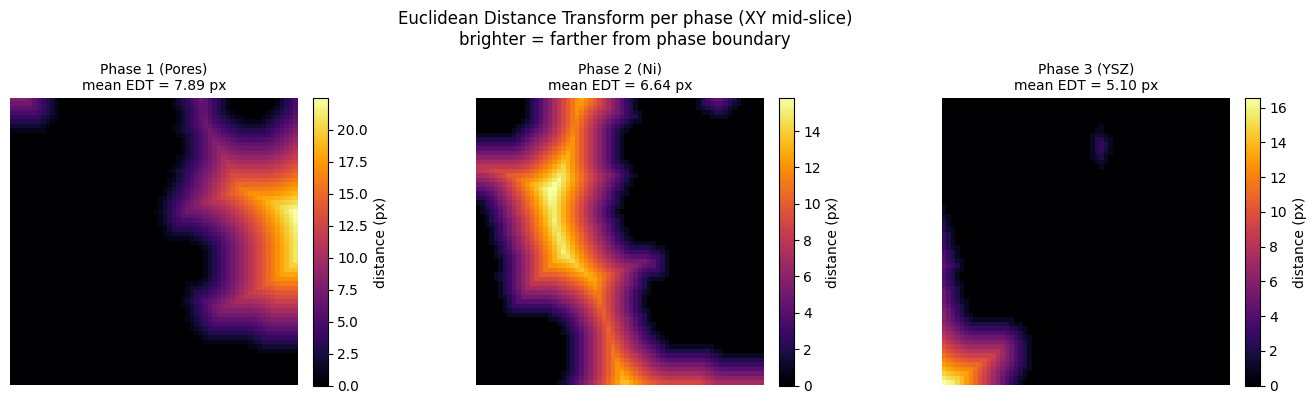

In [39]:
# Visualise the EDT for each phase in the mid-slice of the first subvolume
mid_z = sv.shape[2] // 2
slice_2d = sv[:, :, mid_z]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ph in enumerate(phases):
    mask_2d = (slice_2d == ph).astype(np.uint8)
    dt = scipy.ndimage.distance_transform_edt(mask_2d)
    im = axes[i].imshow(dt, cmap="inferno", interpolation="nearest")
    axes[i].set_title(f"{PHASE_LABELS[i]}\nmean EDT = {dt[mask_2d > 0].mean():.2f} px", fontsize=10)
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="distance (px)")

fig.suptitle("Euclidean Distance Transform per phase (XY mid-slice)\nbrighter = farther from phase boundary", fontsize=12)
plt.tight_layout()
plt.show()